# 1 Introduction

In [1]:
# Optional: run this only if torch and torchvision are missing in the active environment
# %pip install torch torchvision


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision.datasets as datasets
import torchvision.transforms as transforms

from torch.nn.functional import conv2d, max_pool2d, cross_entropy

plt.rc("figure", dpi=100)

batch_size = 100

# transform images into normalized tensors
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

train_dataset = datasets.MNIST(
    "./",
    download=True,
    train=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    "./",
    download=True,
    train=False,
    transform=transform,
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

# Mark the convolution helpers as intentionally used by the notebook.
_ = (conv2d, max_pool2d)

def init_weights(shape):
    # Kaiming He initialization (a good initialization is important)
    # https://arxiv.org/abs/1502.01852
    std = np.sqrt(2. / shape[0])
    w = torch.randn(size=shape) * std
    w.requires_grad = True
    return w


def rectify(x):
    # Rectified Linear Unit (ReLU)
    return torch.max(torch.zeros_like(x), x)


class RMSprop(optim.Optimizer):
    """
    This is a reduced version of the PyTorch internal RMSprop optimizer
    It serves here as an example
    """
    def __init__(self, params, lr=1e-3, alpha=0.5, eps=1e-8):
        defaults = dict(lr=lr, alpha=alpha, eps=eps)
        super(RMSprop, self).__init__(params, defaults)

    def step(self):
        for group in self.param_groups:
            for p in group['params']:
                grad = p.grad.data
                state = self.state[p]

                # state initialization
                if len(state) == 0:
                    state['square_avg'] = torch.zeros_like(p.data)

                square_avg = state['square_avg']
                alpha = group['alpha']

                # update running averages
                square_avg.mul_(alpha).addcmul_(grad, grad, value=1 - alpha)
                avg = square_avg.sqrt().add_(group['eps'])

                # gradient update
                p.data.addcdiv_(grad, avg, value=-group['lr'])


# define the neural network

def model(x, w_h, w_h2, w_o):
    h = rectify(x @ w_h)
    h2 = rectify(h @ w_h2)
    pre_softmax = h2 @ w_o
    return pre_softmax


Epoch: 0
Mean Train Loss: 3.93e-01
Mean Test Loss:  1.89e-01
Test Error:      5.46%
Epoch: 10
Mean Train Loss: 1.43e-01
Mean Test Loss:  2.30e-01
Test Error:      2.24%
Epoch: 20
Mean Train Loss: 1.10e-01
Mean Test Loss:  5.33e-01
Test Error:      2.47%
Epoch: 30
Mean Train Loss: 7.19e-02
Mean Test Loss:  5.99e-01
Test Error:      2.32%
Epoch: 40
Mean Train Loss: 5.17e-02
Mean Test Loss:  8.18e-01
Test Error:      2.32%
Epoch: 50
Mean Train Loss: 4.24e-02
Mean Test Loss:  7.20e-01
Test Error:      1.91%
Epoch: 60
Mean Train Loss: 2.27e-02
Mean Test Loss:  8.43e-01
Test Error:      1.83%
Epoch: 70
Mean Train Loss: 2.09e-02
Mean Test Loss:  8.84e-01
Test Error:      1.78%
Epoch: 80
Mean Train Loss: 2.00e-02
Mean Test Loss:  9.32e-01
Test Error:      2.03%
Epoch: 90
Mean Train Loss: 1.19e-02
Mean Test Loss:  9.88e-01
Test Error:      1.99%
Epoch: 100
Mean Train Loss: 7.43e-03
Mean Test Loss:  9.33e-01
Test Error:      1.69%


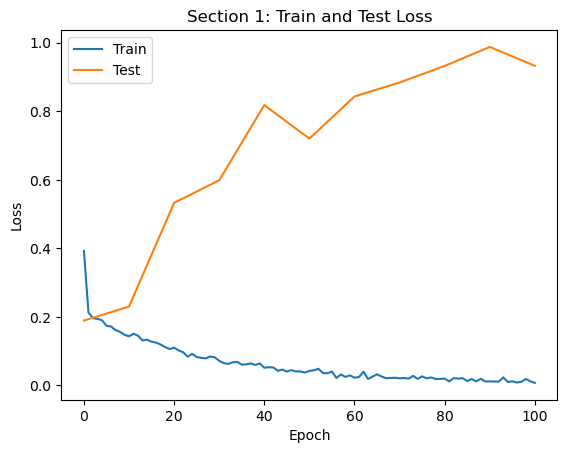

In [3]:
# Train and evaluate the baseline fully connected network from Section 1.
# These variables are used again in the final overview table.

# input shape is (B, 784)
w_h_sec1 = init_weights((784, 625))
w_h2_sec1 = init_weights((625, 625))
w_o_sec1 = init_weights((625, 10))

optimizer_sec1 = RMSprop(params=[w_h_sec1, w_h2_sec1, w_o_sec1])

n_epochs_sec1 = 100
train_loss_sec1 = []
test_loss_sec1 = []
test_error_sec1 = []

for epoch in range(n_epochs_sec1 + 1):
    train_loss_this_epoch = []

    for x, y in train_dataloader:
        x = x.reshape(-1, 784)
        logits = model(x, w_h_sec1, w_h2_sec1, w_o_sec1)

        optimizer_sec1.zero_grad()
        loss = cross_entropy(logits, y, reduction="mean")
        train_loss_this_epoch.append(float(loss.detach()))
        loss.backward()
        optimizer_sec1.step()

    train_loss_sec1.append(float(np.mean(train_loss_this_epoch)))

    if epoch % 10 == 0:
        test_loss_this_epoch = []
        n_correct = 0
        n_total = 0

        with torch.no_grad():
            for x, y in test_dataloader:
                x = x.reshape(-1, 784)
                logits = model(x, w_h_sec1, w_h2_sec1, w_o_sec1)
                loss = cross_entropy(logits, y, reduction="mean")
                test_loss_this_epoch.append(float(loss.detach()))

                predictions = torch.argmax(logits, dim=1)
                n_correct += int((predictions == y).sum().item())
                n_total += int(y.shape[0])

        test_loss_sec1.append(float(np.mean(test_loss_this_epoch)))
        test_error_sec1.append(1.0 - n_correct / n_total)

        print(f"Epoch: {epoch}")
        print(f"Mean Train Loss: {train_loss_sec1[-1]:.2e}")
        print(f"Mean Test Loss:  {test_loss_sec1[-1]:.2e}")
        print(f"Test Error:      {test_error_sec1[-1]:.2%}")

plt.plot(np.arange(n_epochs_sec1 + 1), train_loss_sec1, label="Train")
plt.plot(np.arange(0, n_epochs_sec1 + 1, 10), test_loss_sec1, label="Test")
plt.title("Section 1: Train and Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

sec1_train_loss = train_loss_sec1[-1]
sec1_test_loss = test_loss_sec1[-1]
sec1_test_error = test_error_sec1[-1]


# 2 Dropout

In [4]:
# Sets random elements of X to zero (do not use pytorch's existing drop out functionality)
def dropout(X, p_drop=0.5):
    if 0 < p_drop < 1:
        for i in range(len(X)):
            if np.random.binomial(1, p_drop, 1):
                X[i] = 0
            else:
                X[i] = X[i] / (1 - p_drop)

    return X

# Define the neural network but now with 3 drop out steps
def dropout_model(X, w_h, w_h2, w_o, p_drop_input, p_drop_hidden):
    X = dropout(X, p_drop_input)
    h = rectify(X @ w_h)

    h = dropout(h, p_drop_hidden)
    h2 = rectify(h @ w_h2)

    h2 = dropout(h2, p_drop_hidden)
    pre_softmax = h2 @ w_o

    return pre_softmax

In [ ]:
plt.rc("figure", dpi=100)

batch_size = 100

# transform images into normalized tensors
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

train_dataset = datasets.MNIST(
    "./",
    download=True,
    train=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    "./",
    download=True,
    train=False,
    transform=transform,
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

def init_weights(shape):
    # Kaiming He initialization (a good initialization is important)
    # https://arxiv.org/abs/1502.01852
    std = np.sqrt(2. / shape[0])
    w = torch.randn(size=shape) * std
    w.requires_grad = True
    return w


def rectify(x):
    # Rectified Linear Unit (ReLU)
    return torch.max(torch.zeros_like(x), x)


class RMSprop(optim.Optimizer):
    """
    This is a reduced version of the PyTorch internal RMSprop optimizer
    It serves here as an example
    """
    def __init__(self, params, lr=1e-3, alpha=0.5, eps=1e-8):
        defaults = dict(lr=lr, alpha=alpha, eps=eps)
        super(RMSprop, self).__init__(params, defaults)

    def step(self):
        for group in self.param_groups:
            for p in group['params']:
                grad = p.grad.data
                state = self.state[p]

                # state initialization
                if len(state) == 0:
                    state['square_avg'] = torch.zeros_like(p.data)

                square_avg = state['square_avg']
                alpha = group['alpha']

                # update running averages
                square_avg.mul_(alpha).addcmul_(grad, grad, value=1 - alpha)
                avg = square_avg.sqrt().add_(group['eps'])

                # gradient update
                p.data.addcdiv_(grad, avg, value=-group['lr'])

# initialize weights

# input shape is (B, 784)
w_h = init_weights((784, 625))
# hidden layer with 625 neurons
w_h2 = init_weights((625, 625))
# hidden layer with 625 neurons
w_o = init_weights((625, 10))
# output shape is (B, 10)

optimizer = RMSprop(params=[w_h, w_h2, w_o])


n_epochs = 100

train_loss = []
test_loss = []

# put this into a training loop over 100 epochs
for epoch in range(n_epochs + 1):
    train_loss_this_epoch = []
    for idx, batch in enumerate(train_dataloader):
        x, y = batch

        # our model requires flattened input
        x = x.reshape(batch_size, 784)
        # feed input through model
        noise_py_x = dropout_model(x, w_h, w_h2, w_o, 0.1, 0.5)

        # reset the gradient
        optimizer.zero_grad()

        # the cross-entropy loss function already contains the softmax
        loss = cross_entropy(noise_py_x, y, reduction="mean")

        train_loss_this_epoch.append(float(loss))

        # compute the gradient
        loss.backward()
        # update weights
        optimizer.step()

    train_loss.append(np.mean(train_loss_this_epoch))

    # test periodically
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}")
        print(f"Mean Train Loss: {train_loss[-1]:.2e}")
        test_loss_this_epoch = []

        # no need to compute gradients for validation
        with torch.no_grad():
            for idx, batch in enumerate(test_dataloader):
                x, y = batch
                x = x.reshape(batch_size, 784)
                noise_py_x = model(x, w_h, w_h2, w_o)

                loss = cross_entropy(noise_py_x, y, reduction="mean")
                test_loss_this_epoch.append(float(loss))

        test_loss.append(np.mean(test_loss_this_epoch))

        print(f"Mean Test Loss:  {test_loss[-1]:.2e}")

plt.plot(np.arange(n_epochs + 1), train_loss, label="Train")
plt.plot(np.arange(1, n_epochs + 2, 10), test_loss, label="Test")
plt.title("Train and Test Loss over Training")
plt.xlabel("Epoch")

plt.ylabel("Loss")
plt.legend()

# Store Section 2 results for the final overview table.
n_correct = 0
n_total = 0

with torch.no_grad():
    for x, y in test_dataloader:
        x = x.reshape(-1, 784)
        # Dropout is switched off for evaluation by using the plain model.
        logits = model(x, w_h, w_h2, w_o)
        predictions = torch.argmax(logits, dim=1)
        n_correct += int((predictions == y).sum().item())
        n_total += int(y.shape[0])

sec2_train_loss = train_loss[-1]
sec2_test_loss = test_loss[-1]
sec2_test_error = 1.0 - n_correct / n_total

print(f"Section 2 final test error: {sec2_test_error:.2%}")


Epoch: 0
Mean Train Loss: 2.05e+00
Mean Test Loss:  4.56e-01
Epoch: 10
Mean Train Loss: 1.91e+00
Mean Test Loss:  1.62e-01
Epoch: 20
Mean Train Loss: 1.90e+00
Mean Test Loss:  2.02e-01
Epoch: 30
Mean Train Loss: 1.90e+00
Mean Test Loss:  1.53e-01


Task: Explain in a few sentences how the dropout method works and how it reduces overfitting. Train the model using dropout and report train and test errors. Why do we need a different model configuration for evaluating the test loss? Compare the test error with the test error from Section 1.

The dropout method works by setting random elements to zeros in each layer in the neural network. This reduces overfitting because it adds noise to the training data so the model can't perfectly align to the exact data. It forces the neural network to learn in a more unpredictable and less singular way so it is less affected by overfitting. We need a different model configuration for evaluting the test loss because the randomization in dropout means we need to evaluate it against the no dropout model to get an accurate test evaluation.

Test Error Comparison
| Method    | Mean Train Loss   | Mean Test Loss    |
| --------- | ----------------- | ----------------- |
| No Dropout| 1.45e-02          | 9.31e-01          |
| Dropout   | 1.83e+00          | 2.33e-01          |

As we can see from the results the testing error has drastically decreased in comparison to the no dropout model. This testing error implies that there is less overfitting in the model compared to the no dropout method. The dropout model has slightly worse mean training loss as a result though. The variables of p_drop_hidden could be adjusted to something lower which might improve the training loss.

# 3 Parametric ReLU


In [ ]:
# Sets random elements of X to zero (do not use pytorch's existing drop out functionality)
def dropout(X, p_drop=0.5):
    if 0 < p_drop < 1:
        for i in range(len(X)):
            if np.random.binomial(1, p_drop, 1):
                X[i] = 0
            else:
                X[i] = X[i] / (1 - p_drop)

    return X

def rectify(x, a=0):
    # Rectified Linear Unit (ReLU)
    return torch.max(torch.zeros_like(x), x) + a * torch.min(torch.zeros_like(x), x)


# Define the neural network but now with 3 drop out steps
def dropout_model(X, w_h, w_h2, w_o, p_drop_input, p_drop_hidden):
    X = dropout(X, p_drop_input)
    h = rectify(X @ w_h)

    h = dropout(h, p_drop_hidden)
    h2 = rectify(h @ w_h2)

    h2 = dropout(h2, p_drop_hidden)
    pre_softmax = h2 @ w_o

    return pre_softmax

def parametric_dropout_model(X, w_h, w_h2, w_o, p_drop_input, p_drop_hidden, a1=0, a2=0):
    X = dropout(X, p_drop_input)
    h = rectify(X @ w_h, a=a1)

    h = dropout(h, p_drop_hidden)
    h2 = rectify(h @ w_h2, a=a2)
    
    h2 = dropout(h2, p_drop_hidden)
    pre_softmax = h2 @ w_o

    return pre_softmax


In [ ]:
# Train and evaluate the parametric ReLU model from Section 3.
# This keeps the Section 3 values separate from the later CNN variables.

device = torch.device("cpu")
print(f"Using {device} device")

w_h_sec3 = init_weights((784, 625))
w_h2_sec3 = init_weights((625, 625))
w_o_sec3 = init_weights((625, 10))

a1_sec3 = torch.nn.Parameter(torch.tensor(0.25, dtype=torch.float32), requires_grad=True)
a2_sec3 = torch.nn.Parameter(torch.tensor(0.25, dtype=torch.float32), requires_grad=True)

optimizer_sec3 = RMSprop(params=[w_h_sec3, w_h2_sec3, w_o_sec3, a1_sec3, a2_sec3])

n_epochs_sec3 = 100
train_loss_sec3 = []
test_loss_sec3 = []
test_error_sec3 = []

for epoch in range(n_epochs_sec3 + 1):
    train_loss_this_epoch = []

    for x, y in train_dataloader:
        x = x.reshape(-1, 784)
        logits = parametric_dropout_model(
            x, w_h_sec3, w_h2_sec3, w_o_sec3,
            p_drop_input=0.1,
            p_drop_hidden=0.5,
            a1=a1_sec3,
            a2=a2_sec3,
        )

        optimizer_sec3.zero_grad()
        loss = cross_entropy(logits, y, reduction="mean")
        train_loss_this_epoch.append(float(loss.detach()))
        loss.backward()
        optimizer_sec3.step()

    train_loss_sec3.append(float(np.mean(train_loss_this_epoch)))

    if epoch % 10 == 0:
        test_loss_this_epoch = []
        n_correct = 0
        n_total = 0

        with torch.no_grad():
            for x, y in test_dataloader:
                x = x.reshape(-1, 784)
                logits = parametric_dropout_model(
                    x, w_h_sec3, w_h2_sec3, w_o_sec3,
                    p_drop_input=0.0,
                    p_drop_hidden=0.0,
                    a1=a1_sec3,
                    a2=a2_sec3,
                )
                loss = cross_entropy(logits, y, reduction="mean")
                test_loss_this_epoch.append(float(loss.detach()))

                predictions = torch.argmax(logits, dim=1)
                n_correct += int((predictions == y).sum().item())
                n_total += int(y.shape[0])

        test_loss_sec3.append(float(np.mean(test_loss_this_epoch)))
        test_error_sec3.append(1.0 - n_correct / n_total)

        print(f"Epoch: {epoch}")
        print(f"Mean Train Loss: {train_loss_sec3[-1]:.2e}")
        print(f"Mean Test Loss:  {test_loss_sec3[-1]:.2e}")
        print(f"Test Error:      {test_error_sec3[-1]:.2%}")
        print(f"a1: {a1_sec3.item():.2e}, a2: {a2_sec3.item():.2e}")

plt.plot(np.arange(n_epochs_sec3 + 1), train_loss_sec3, label="Train")
plt.plot(np.arange(0, n_epochs_sec3 + 1, 10), test_loss_sec3, label="Test")
plt.title("Section 3: Parametric ReLU Train and Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

sec3_train_loss = train_loss_sec3[-1]
sec3_test_loss = test_loss_sec3[-1]
sec3_test_error = test_error_sec3[-1]


## 4 Convolution network

### Shape calculation for 4.1

The CNN uses valid convolutions, i.e. no padding. Therefore the spatial sizes are:

- Input: `1 × 28 × 28`
- Conv1 `32` filters of size `5 × 5`: `32 × 24 × 24`, then max-pooling: `32 × 12 × 12`
- Conv2 `64` filters of size `5 × 5`: `64 × 8 × 8`, then max-pooling: `64 × 4 × 4`
- Conv3 `128` filters of size `3 × 3`: `128 × 2 × 2`, then max-pooling: `128 × 1 × 1`

So the flattened size is `128 · 1 · 1 = 128`, hence `w_h2 = init_weights((128, 625))`.


In [ ]:

# 4.1 Convolutional network for MNIST
# Architecture:
# input 1x28x28
# -> conv(32, 5x5) -> ReLU -> maxpool(2x2) -> dropout  => 32x12x12
# -> conv(64, 5x5) -> ReLU -> maxpool(2x2) -> dropout  => 64x4x4
# -> conv(128, 3x3) -> ReLU -> maxpool(2x2) -> dropout => 128x1x1
# -> flatten -> dense(625) -> ReLU -> dropout -> dense(10)

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.nn.functional import conv2d, max_pool2d, cross_entropy

# Use GPU/MPS if available, otherwise CPU.
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

torch.manual_seed(0)
np.random.seed(0)

plt.rc("figure", dpi=100)
batch_size = 100

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,)),
])

train_dataset = datasets.MNIST("./", download=True, train=True, transform=transform)
test_dataset = datasets.MNIST("./", download=True, train=False, transform=transform)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)


def init_weights(shape):
    """Kaiming-He-like initialization for dense and convolutional weights."""
    if len(shape) == 4:
        # conv2d weight shape: (out_channels, in_channels, kernel_x, kernel_y)
        fan_in = shape[1] * shape[2] * shape[3]
    else:
        fan_in = shape[0]
    std = np.sqrt(2.0 / fan_in)
    w = torch.randn(size=shape, device=device) * std
    w.requires_grad = True
    return w


def rectify(x):
    return torch.max(torch.zeros_like(x), x)


def dropout(x, p_drop=0.5):
    """Inverted dropout, without torch.nn.functional.dropout."""
    if 0 < p_drop < 1:
        keep_prob = 1.0 - p_drop
        mask = torch.bernoulli(torch.full_like(x, keep_prob))
        return x * mask / keep_prob
    return x


class RMSprop(optim.Optimizer):
    """Reduced RMSprop optimizer from the exercise sheet."""
    def __init__(self, params, lr=1e-3, alpha=0.5, eps=1e-8):
        defaults = dict(lr=lr, alpha=alpha, eps=eps)
        super(RMSprop, self).__init__(params, defaults)

    def step(self):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                grad = p.grad.data
                state = self.state[p]
                if len(state) == 0:
                    state["square_avg"] = torch.zeros_like(p.data)

                square_avg = state["square_avg"]
                alpha = group["alpha"]
                square_avg.mul_(alpha).addcmul_(grad, grad, value=1 - alpha)
                avg = square_avg.sqrt().add_(group["eps"])
                p.data.addcdiv_(grad, avg, value=-group["lr"])


def cnn_model(x, w_c1, w_c2, w_c3, w_h2, w_o,
              p_drop_input=0.1, p_drop_hidden=0.5):
    # Important: input must be (batch, channels, height, width) = (B, 1, 28, 28)
    x = dropout(x, p_drop_input)

    h = rectify(conv2d(x, w_c1))
    h = max_pool2d(h, (2, 2))
    h = dropout(h, p_drop_hidden)

    h = rectify(conv2d(h, w_c2))
    h = max_pool2d(h, (2, 2))
    h = dropout(h, p_drop_hidden)

    h = rectify(conv2d(h, w_c3))
    h = max_pool2d(h, (2, 2))
    h = dropout(h, p_drop_hidden)

    h = torch.reshape(h, (h.shape[0], -1))  # (B, 128)
    h2 = rectify(h @ w_h2)                  # (B, 625)
    h2 = dropout(h2, p_drop_hidden)
    pre_softmax = h2 @ w_o                  # (B, 10)
    return pre_softmax


# Required convolutional weights from the exercise sheet.
w_c1 = init_weights((32, 1, 5, 5))
w_c2 = init_weights((64, 32, 5, 5))
w_c3 = init_weights((128, 64, 3, 3))

# Shape check:
# 28 -> conv5: 24 -> pool2: 12
# 12 -> conv5:  8 -> pool2:  4
#  4 -> conv3:  2 -> pool2:  1
# Last feature map: 128 x 1 x 1, therefore number_of_output_pixel = 128.
number_of_output_pixel = 128
w_h2 = init_weights((number_of_output_pixel, 625))
w_o = init_weights((625, 10))

params = [w_c1, w_c2, w_c3, w_h2, w_o]
optimizer = RMSprop(params=params, lr=1e-3, alpha=0.5, eps=1e-8)

# Quick sanity check: output must be (batch_size, 10).
x_check, y_check = next(iter(train_dataloader))
x_check = x_check.reshape(-1, 1, 28, 28).to(device)
with torch.no_grad():
    y_pred_check = cnn_model(x_check, w_c1, w_c2, w_c3, w_h2, w_o, 0.0, 0.0)
print("Sanity-check output shape:", tuple(y_pred_check.shape))

# Training. For the final submission you can increase this to e.g. 20, 50, or 100.
n_epochs = 10
train_loss = []
test_loss = []

for epoch in range(n_epochs + 1):
    train_loss_this_epoch = []

    for x, y in train_dataloader:
        # The exercise explicitly requires this shape for the CNN input.
        x = x.reshape(-1, 1, 28, 28).to(device)
        y = y.to(device)

        pred = cnn_model(x, w_c1, w_c2, w_c3, w_h2, w_o,
                         p_drop_input=0.1, p_drop_hidden=0.5)

        optimizer.zero_grad()
        loss = cross_entropy(pred, y, reduction="mean")
        train_loss_this_epoch.append(float(loss.detach().cpu()))
        loss.backward()
        optimizer.step()

    train_loss.append(float(np.mean(train_loss_this_epoch)))

    # Evaluation: dropout must be switched off for a deterministic test loss.
    test_loss_this_epoch = []
    with torch.no_grad():
        for x, y in test_dataloader:
            x = x.reshape(-1, 1, 28, 28).to(device)
            y = y.to(device)

            pred = cnn_model(x, w_c1, w_c2, w_c3, w_h2, w_o,
                             p_drop_input=0.0, p_drop_hidden=0.0)
            loss = cross_entropy(pred, y, reduction="mean")
            test_loss_this_epoch.append(float(loss.detach().cpu()))

    test_loss.append(float(np.mean(test_loss_this_epoch)))

    print(f"Epoch: {epoch}")
    print(f"Mean Train Loss: {train_loss[-1]:.2e}")
    print(f"Mean Test Loss:  {test_loss[-1]:.2e}")

plt.plot(np.arange(n_epochs + 1), train_loss, label="Train")
plt.plot(np.arange(n_epochs + 1), test_loss, label="Test")
plt.title("CNN Train and Test Loss over Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


## 4.2 Application of Convolutional Network



### CNN-Sketch

![output.png](./output.png)

Bild mit den Filterausgaben und der CNN-Übersicht.

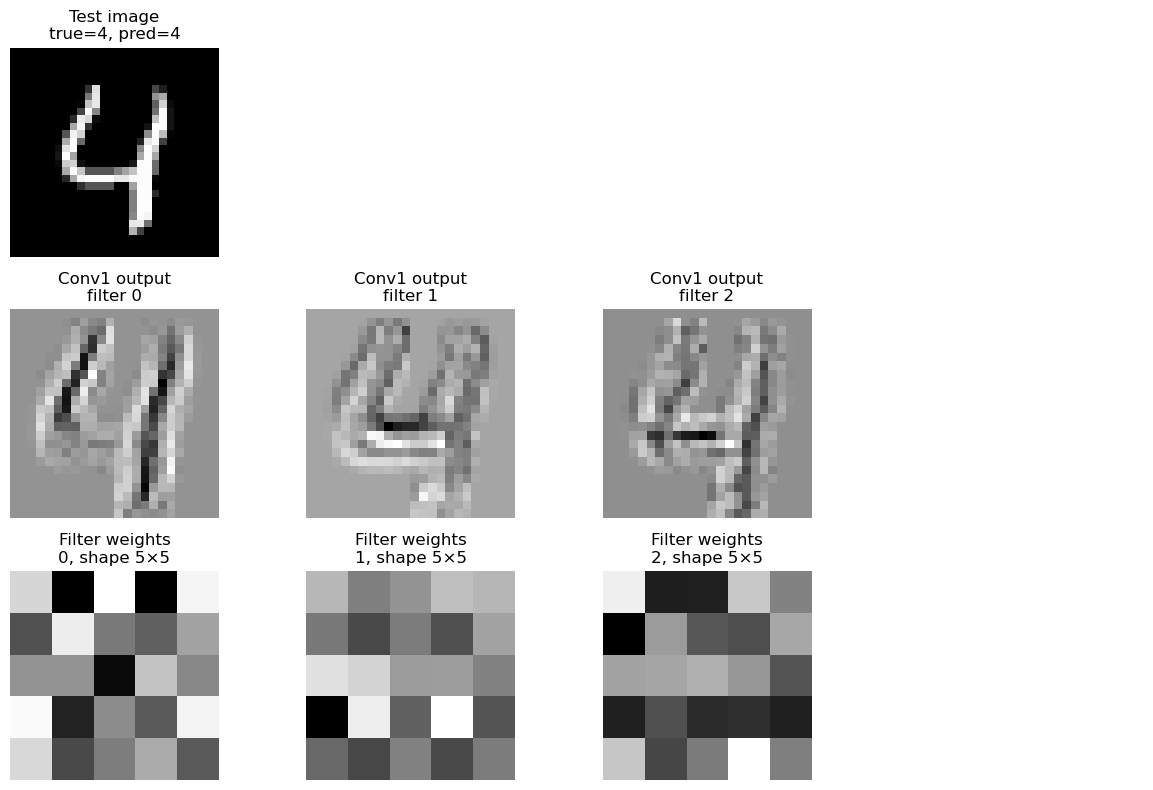

In [ ]:
# Plot one test image, its convolution with 3 filters from the first conv layer,
# and the corresponding 5x5 filter weights.

filter_indices = [0, 1, 2]

x_test_batch, y_test_batch = next(iter(test_dataloader))
image = x_test_batch[4:5].reshape(1, 1, 28, 28).to(device)
true_label = int(y_test_batch[4].item())

with torch.no_grad():
    logits = cnn_model(
        image, w_c1, w_c2, w_c3, w_h2, w_o,
        p_drop_input=0.0, p_drop_hidden=0.0,
    )
    predicted_label = int(torch.argmax(logits, dim=1).item())

    # Raw convolution output of the first convolutional layer, before ReLU/pooling/dropout.
    first_conv_output = conv2d(image, w_c1)

# De-normalize MNIST image only for display: original transform was (x - 0.5) / 0.5.
image_for_plot = (image[0, 0].detach().cpu() * 0.5 + 0.5).clamp(0, 1)

fig, axes = plt.subplots(3, 4, figsize=(12, 8))

# First row: original image only.
axes[0, 0].imshow(image_for_plot, cmap="gray")
axes[0, 0].set_title(f"Test image\ntrue={true_label}, pred={predicted_label}")
axes[0, 0].axis("off")

for col in range(1, 4):
    axes[0, col].axis("off")

# Second row: convolution responses / feature maps.
for col, filter_idx in enumerate(filter_indices):
    activation = first_conv_output[0, filter_idx].detach().cpu()
    axes[1, col].imshow(activation, cmap="gray")
    axes[1, col].set_title(f"Conv1 output\nfilter {filter_idx}")
    axes[1, col].axis("off")
axes[1, 3].axis("off")

# Third row: corresponding 5x5 filter weights.
for col, filter_idx in enumerate(filter_indices):
    filt = w_c1[filter_idx, 0].detach().cpu()
    axes[2, col].imshow(filt, cmap="gray")
    axes[2, col].set_title(f"Filter weights\n{filter_idx}, shape 5×5")
    axes[2, col].axis("off")
axes[2, 3].axis("off")

plt.tight_layout()
plt.show()


### remove third convolutional layer


In [ ]:
# Helper functions for evaluation and training in 4.2

def evaluate_loss_and_error(model_call, dataloader):
    """Return mean cross-entropy loss and classification error."""
    losses = []
    n_correct = 0
    n_total = 0

    with torch.no_grad():
        for x, y in dataloader:
            x = x.reshape(-1, 1, 28, 28).to(device)
            y = y.to(device)

            logits = model_call(x, p_drop_input=0.0, p_drop_hidden=0.0)
            loss = cross_entropy(logits, y, reduction="mean")
            losses.append(float(loss.detach().cpu()))

            predictions = torch.argmax(logits, dim=1)
            n_correct += int((predictions == y).sum().item())
            n_total += int(y.shape[0])

    mean_loss = float(np.mean(losses))
    error = 1.0 - n_correct / n_total
    return mean_loss, error


# Evaluate the already trained 3-convolution CNN from Aufgabe 4.1.
cnn_3conv_call = lambda x, p_drop_input=0.0, p_drop_hidden=0.0: cnn_model(
    x, w_c1, w_c2, w_c3, w_h2, w_o,
    p_drop_input=p_drop_input,
    p_drop_hidden=p_drop_hidden,
)

cnn_3conv_test_loss, cnn_3conv_test_error = evaluate_loss_and_error(cnn_3conv_call, test_dataloader)
print(f"3-conv CNN test loss:  {cnn_3conv_test_loss:.4f}")
print(f"3-conv CNN test error: {cnn_3conv_test_error:.4%}")


In [ ]:
# Two-convolution-layer variant: remove the third convolutional layer.

def cnn_model_two_conv(x, w2_c1, w2_c2, w2_h2, w2_o,
                       p_drop_input=0.1, p_drop_hidden=0.5):
    x = dropout(x, p_drop_input)

    h = rectify(conv2d(x, w2_c1))
    h = max_pool2d(h, (2, 2))
    h = dropout(h, p_drop_hidden)

    h = rectify(conv2d(h, w2_c2))
    h = max_pool2d(h, (2, 2))
    h = dropout(h, p_drop_hidden)

    h = torch.reshape(h, (h.shape[0], -1))  # (B, 64*4*4) = (B, 1024)
    h2 = rectify(h @ w2_h2)
    h2 = dropout(h2, p_drop_hidden)
    pre_softmax = h2 @ w2_o
    return pre_softmax


# Initialize weights for the variant.
w2_c1 = init_weights((32, 1, 5, 5))
w2_c2 = init_weights((64, 32, 5, 5))
number_of_output_pixel_two_conv = 64 * 4 * 4
w2_h2 = init_weights((number_of_output_pixel_two_conv, 625))
w2_o = init_weights((625, 10))

params_two_conv = [w2_c1, w2_c2, w2_h2, w2_o]
optimizer_two_conv = RMSprop(params=params_two_conv, lr=1e-3, alpha=0.5, eps=1e-8)

# For the final hand-in increase this, e.g. to 20, 50, or 100.
n_epochs_two_conv = 10
train_loss_two_conv = []
test_loss_two_conv = []
test_error_two_conv = []

for epoch in range(n_epochs_two_conv + 1):
    train_loss_this_epoch = []

    for x, y in train_dataloader:
        x = x.reshape(-1, 1, 28, 28).to(device)
        y = y.to(device)

        logits = cnn_model_two_conv(
            x, w2_c1, w2_c2, w2_h2, w2_o,
            p_drop_input=0.1, p_drop_hidden=0.5,
        )

        optimizer_two_conv.zero_grad()
        loss = cross_entropy(logits, y, reduction="mean")
        train_loss_this_epoch.append(float(loss.detach().cpu()))
        loss.backward()
        optimizer_two_conv.step()

    train_loss_two_conv.append(float(np.mean(train_loss_this_epoch)))

    two_conv_call = lambda x, p_drop_input=0.0, p_drop_hidden=0.0: cnn_model_two_conv(
        x, w2_c1, w2_c2, w2_h2, w2_o,
        p_drop_input=p_drop_input,
        p_drop_hidden=p_drop_hidden,
    )
    loss_eval, error_eval = evaluate_loss_and_error(two_conv_call, test_dataloader)
    test_loss_two_conv.append(loss_eval)
    test_error_two_conv.append(error_eval)

    print(f"Epoch: {epoch}")
    print(f"Two-conv mean train loss: {train_loss_two_conv[-1]:.2e}")
    print(f"Two-conv mean test loss:  {test_loss_two_conv[-1]:.2e}")
    print(f"Two-conv test error:      {test_error_two_conv[-1]:.2%}")

plt.plot(np.arange(n_epochs_two_conv + 1), train_loss_two_conv, label="Train, two-conv")
plt.plot(np.arange(n_epochs_two_conv + 1), test_loss_two_conv, label="Test, two-conv")
plt.title("Two-conv CNN train and test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [ ]:
# Overview table for all sections.
# Run Sections 1--4 first so all sec*_ variables exist.

import pandas as pd

rows = [
    {
        "Section": "1",
        "Model": "Fully connected network",
        "Final train loss": sec1_train_loss,
        "Final test loss": sec1_test_loss,
        "Final test error": sec1_test_error,
    },
    {
        "Section": "2",
        "Model": "Fully connected + dropout",
        "Final train loss": sec2_train_loss,
        "Final test loss": sec2_test_loss,
        "Final test error": sec2_test_error,
    },
    {
        "Section": "3",
        "Model": "Parametric ReLU + dropout",
        "Final train loss": sec3_train_loss,
        "Final test loss": sec3_test_loss,
        "Final test error": sec3_test_error,
    },
    {
        "Section": "4.1 / 4.2",
        "Model": "CNN, 3 convolutional layers",
        "Final train loss": train_loss[-1],
        "Final test loss": cnn_3conv_test_loss,
        "Final test error": cnn_3conv_test_error,
    },
    {
        "Section": "4.2 variant",
        "Model": "CNN, 2 convolutional layers",
        "Final train loss": train_loss_two_conv[-1],
        "Final test loss": test_loss_two_conv[-1],
        "Final test error": test_error_two_conv[-1],
    },
]

results_all_sections = pd.DataFrame(rows)
results_all_sections["Final test error (%)"] = 100 * results_all_sections["Final test error"]
display(results_all_sections)
